# Explainable NLP Framework for Early Mental Health Risk Detection from Social Media

## Activity 1: Dataset Audit and Initial Analysis

### Objective

The purpose of this notebook is to inspect and understand the dataset selected for the proposed NLP-based mental health risk detection framework.

The dataset will be examined to understand:

- Dataset size and structure
- Available features and target variable
- Missing values
- Duplicate records
- Distribution of mental health risk classes
- Characteristics of the textual data
- Representative examples of social-media text

This initial analysis will help us design the data preprocessing and NLP methodology for the proposed system.

## 1. Import Required Libraries

The following Python libraries are used for dataset loading, data analysis, numerical operations, and visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The dataset contains social-media text along with a corresponding mental health risk category.

The `statement` column represents the textual input, while the `status` column represents the target variable used for risk classification.

In [4]:
# Load the dataset
df = pd.read_csv("/content/Reddit_risk_analysis.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (47894, 3)


,Unnamed: 0,statement,status
0,0,oh my gosh,2
1,1,"trouble sleeping, confused mind, restless heart. All out of tune",2
2,2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",2
3,3,I've shifted my focus to something else but I'm still worried,2
4,4,"I'm restless and restless, it's been a month now, boy. What do you mean?",2


## 3. Dataset Structure

In this step, we examine the number of records, number of attributes, column names, and data types.

Understanding the dataset structure is important before designing the NLP preprocessing pipeline.

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

Number of rows: 47894
Number of columns: 3

Column Names:
['Unnamed: 0', 'statement', 'status']

Data Types:


,0
Unnamed: 0,int64
statement,object
status,int64


## 4. Dataset Information

The dataset is inspected for its overall memory usage, non-null values, and data types.

This helps identify whether any columns require conversion or additional preprocessing.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47894 entries, 0 to 47893
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  47894 non-null  int64 
 1   statement   47894 non-null  object
 2   status      47894 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.1+ MB


## 5. Missing Value Analysis

Missing or null text records can affect NLP processing and model training.

Therefore, the number of missing values in each column is checked before further processing.

In [7]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:


,0
Unnamed: 0,0
statement,0
status,0



Total missing values: 0


## 6. Duplicate Record Analysis

Duplicate records may introduce bias during model training and evaluation.

Therefore, duplicate rows are identified before preprocessing.

In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 7. Target Variable Analysis

The `status` column is the target variable for the proposed mental health risk classification task.

We examine the number of records belonging to each target class to understand the class distribution and identify possible class imbalance.

In [9]:
class_counts = df["status"].value_counts().sort_index()

print("Number of records in each status class:")
display(class_counts)

print("\nPercentage distribution:")
class_percentage = (class_counts / len(df)) * 100
display(class_percentage.round(2))

Number of records in each status class:


,count
status,
0,12064
1,16343
2,19487



Percentage distribution:


,count
status,
0,25.19
1,34.12
2,40.69


## 8. Mental Health Risk Class Distribution

The following visualization shows the distribution of records across the available mental health risk classes.

This analysis is important because class imbalance can influence the performance of classification models and will be considered during the later model evaluation stage.


## 8.1 Interpreting the Risk Classes

According to the dataset documentation, the numerical target labels correspond to three mental health risk levels:

- **0 – High Risk:** Explicit suicidal ideation, suicide planning, self-harm intent, or immediate crisis.
- **1 – Low Risk:** General discussions, emotionally neutral posts, or non-crisis mental health conversations.
- **2 – Moderate Risk:** Depression, anxiety, emotional distress, hopelessness, stress, or substance abuse without explicit suicidal intent.

These labels are used for research-oriented risk classification and should not be interpreted as clinical diagnoses.

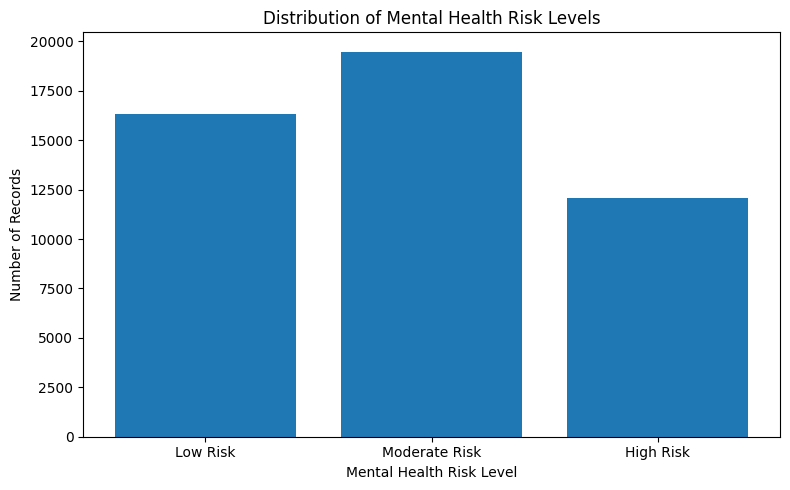

In [15]:
# Map numerical labels to meaningful risk levels
risk_labels = {
    0: "High Risk",
    1: "Low Risk",
    2: "Moderate Risk"
}

risk_counts = df["status"].map(risk_labels).value_counts()

# Keep a meaningful order
risk_order = ["Low Risk", "Moderate Risk", "High Risk"]
risk_counts = risk_counts.reindex(risk_order)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Distribution of Mental Health Risk Levels")
plt.xlabel("Mental Health Risk Level")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## 9. Text Data Inspection

The `statement` column contains the social-media text that will be processed using Natural Language Processing techniques.

A sample of textual records is examined to understand the type of language present in the dataset.

In [11]:
sample_data = df[["statement", "status"]].sample(
    10,
    random_state=42
)

display(sample_data)

,statement,status
32440,@889grapevine Looking forward to the new website,1
10241,"I have done so much to get here. Financially stable, 7/10 in looks, fit and healthy. I thought Id be happy. I am not. I kept trying to think thing...",0
23598,"So I'm unemployed, broke, no car or drivers licence (its suspended due to unpaid tickets). Unemployment ran out a month ago and I have no savings....",2
36930,myconnecticut restaurant called woodntap ha competitive eating tourney round tourney time we place nd,1
1911,"Have you ever panicked, your friend of the opposite sex has changed his attitude towards you, so he looks at you as a girl, not as a friend of the...",1
8807,They say suicide is selfish but if i decide why cannot i have the option to die peacefully after a certain age? is not it selfish for everyone to ...,0
985,how can i forget when i have work,1
15555,"Honestly I do not know where to start. I have had anxiety since I was little, I do not necessarily have a stresser more like if I get stressed it ...",2
40223,xovince pssht i miss u u don t respond to me,1
33446,i m tired depressed and can t go through this alone anymore i haven t been kind to myself i ve taken a pill because i don t want to stay awake eve...,2


## 10. Text Length Analysis

Text length is examined to understand the characteristics of the textual data.

The number of characters in each statement is calculated. This helps identify variations in the length of social-media statements and supports later decisions regarding preprocessing and feature extraction.

In [12]:
# Calculate text length
df["text_length"] = df["statement"].astype(str).str.len()

print("Text length statistics:")
display(df["text_length"].describe())

Text length statistics:


,text_length
count,47894.000000
mean,550.112102
std,805.462318
min,2.000000
25%,71.000000
50%,291.000000
75%,717.000000
max,27588.000000


## 11. Distribution of Text Length

The histogram below visualizes the distribution of statement lengths in the dataset.

Understanding text-length variation is useful when designing the NLP preprocessing and feature extraction pipeline.

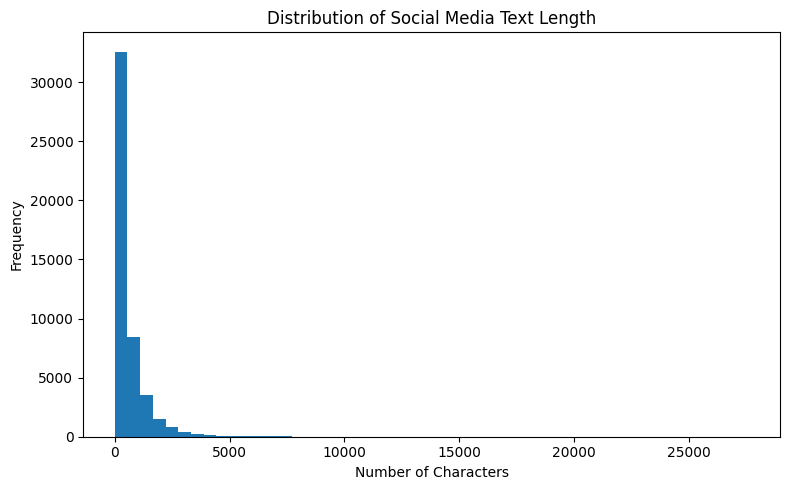

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df["text_length"], bins=50)

plt.title("Distribution of Social Media Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 12. Preliminary Dataset Quality Summary

The initial audit evaluates the dataset in terms of:

- Number of records
- Number of attributes
- Missing values
- Duplicate records
- Target class distribution
- Text characteristics

These observations will be used to design the preprocessing and NLP methodology for the proposed mental health risk detection framework.

In [14]:
print("========== DATASET AUDIT SUMMARY ==========")
print("Total records       :", len(df))
print("Total columns       :", len(df.columns))
print("Missing values      :", df.isnull().sum().sum())
print("Duplicate rows      :", df.duplicated().sum())
print("Text column         : statement")
print("Target column       : status")
print("Number of classes   :", df["status"].nunique())
print("============================================")

========== DATASET AUDIT SUMMARY ==========
Total records       : 47894
Total columns       : 4
Missing values      : 0
Duplicate rows      : 0
Text column         : statement
Target column       : status
Number of classes   : 3


## 13. NLP Preprocessing Plan

Social-media text is often informal and may contain URLs, mentions, hashtags, punctuation, repeated characters, emojis, and other textual noise.

To prepare the text for NLP-based feature extraction and classification, a systematic preprocessing pipeline is proposed.

The preprocessing pipeline consists of:

1. Removing unnecessary index information
2. Handling missing or empty text
3. Removing duplicate records
4. Converting text to lowercase
5. Removing URLs and unnecessary social-media artifacts
6. Handling punctuation and special characters
7. Tokenization
8. Stop-word handling
9. Lemmatization
10. Producing normalized text for feature extraction

The preprocessing decisions are designed to reduce irrelevant variation while preserving meaningful mental-health-related language.

## 14. Creating a Working Dataset

A separate working copy of the dataset is created so that the original dataset remains unchanged.

The index column is not considered a meaningful NLP feature and will therefore be removed from the working dataset.

In [16]:
# Create a working copy
data = df.copy()

# Remove the unnecessary index column
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

print("Working dataset shape:", data.shape)
print("\nRemaining columns:")
print(data.columns.tolist())

display(data.head())

Working dataset shape: (47894, 3)

Remaining columns:
['statement', 'status', 'text_length']


,statement,status,text_length
0,oh my gosh,2,10
1,"trouble sleeping, confused mind, restless heart. All out of tune",2,64
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",2,78
3,I've shifted my focus to something else but I'm still worried,2,61
4,"I'm restless and restless, it's been a month now, boy. What do you mean?",2,72


## 15. Selecting Relevant Columns

For the proposed NLP classification task, the two important fields are:

- `statement` – textual input
- `status` – target risk category

The previously calculated `text_length` field was used only for exploratory analysis and is not part of the primary NLP input.

In [17]:
# Keep only the text and target columns
data = data[["statement", "status"]].copy()

print("Final working columns:")
print(data.columns.tolist())

print("\nWorking dataset shape:", data.shape)

Final working columns:
['statement', 'status']

Working dataset shape: (47894, 2)


## 16. Empty and Missing Text Check

Although the initial dataset audit showed no missing values, empty or whitespace-only statements should also be checked because they do not provide meaningful linguistic information for NLP processing.

In [18]:
# Check for empty or whitespace-only statements
empty_text = data["statement"].astype(str).str.strip().eq("").sum()

print("Empty or whitespace-only statements:", empty_text)

Empty or whitespace-only statements: 0


## 17. Duplicate Text Check

Duplicate textual statements can cause repeated information to appear during model training.

Duplicate records will therefore be identified and removed from the working dataset if necessary.

In [19]:
duplicate_text = data["statement"].duplicated().sum()

print("Duplicate text records:", duplicate_text)

Duplicate text records: 1605


## 18. Basic Text Normalization

The first stage of text normalization converts the text into a consistent format.

The following operations are considered:

- Converting text to lowercase
- Removing URLs
- Removing user mentions
- Reducing unnecessary whitespace

Care is taken not to remove meaningful words that may contribute to mental-health risk identification.

In [20]:
import re

def basic_clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove user mentions
    text = re.sub(r"@\w+", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Demonstrate preprocessing on sample records
sample_text = data["statement"].sample(5, random_state=42)

for original in sample_text:
    cleaned = basic_clean_text(original)

    print("ORIGINAL:")
    print(original)

    print("\nCLEANED:")
    print(cleaned)

    print("\n" + "-"*80 + "\n")

ORIGINAL:
@889grapevine Looking forward to the new website

CLEANED:
looking forward to the new website

--------------------------------------------------------------------------------

ORIGINAL:
I have done so much to get here. Financially stable, 7/10 in looks, fit and healthy. I thought Id be happy. I am not. I kept trying to think things will be different. Thinking that is it, I have made it. But its not enough. I kept being betrayed and used. I feel so dumb and vulnerable. I wish I was anyone but myself. People like me gets sacrificed in movies so other people can live better lives. Is being nice a sin? A sign to other people that you are available to be used and abused? Taken advantage of? I never learn my lesson. I keep giving people second, third chances. I am so tired. Things are no better than they were 10, 15, 20 years ago. Its time to stop trying. Time to end it all. The more you have means you have more to lose. there is no point in any of it. Responsible Suicide

CLEANED

## 19. Tokenization

Tokenization divides each normalized statement into individual words or tokens.

For example:

Original text:

"I feel worried and unable to sleep."

After tokenization:

["i", "feel", "worried", "and", "unable", "to", "sleep"]

Tokenization provides the basic representation required for subsequent NLP preprocessing and feature extraction.

In [21]:
# Install/import NLTK tools
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize

# Select a few sample statements
tokenization_samples = data["statement"].sample(5, random_state=42)

for text in tokenization_samples:
    cleaned = basic_clean_text(text)
    tokens = word_tokenize(cleaned)

    print("Original:")
    print(text)

    print("\nTokens:")
    print(tokens)

    print("\n" + "-" * 80 + "\n")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Original:
@889grapevine Looking forward to the new website

Tokens:
['looking', 'forward', 'to', 'the', 'new', 'website']

--------------------------------------------------------------------------------

Original:
I have done so much to get here. Financially stable, 7/10 in looks, fit and healthy. I thought Id be happy. I am not. I kept trying to think things will be different. Thinking that is it, I have made it. But its not enough. I kept being betrayed and used. I feel so dumb and vulnerable. I wish I was anyone but myself. People like me gets sacrificed in movies so other people can live better lives. Is being nice a sin? A sign to other people that you are available to be used and abused? Taken advantage of? I never learn my lesson. I keep giving people second, third chances. I am so tired. Things are no better than they were 10, 15, 20 years ago. Its time to stop trying. Time to end it all. The more you have means you have more to lose. there is no point in any of it. Responsibl

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 20. Stop-word Handling

Common words such as "the", "is", "and", and "to" may contribute less information to traditional text classification models.

Stop-word removal will therefore be evaluated as part of the preprocessing pipeline.

However, words that may influence the interpretation of mental-health-related language should be preserved wherever appropriate.

In [22]:
nltk.download("stopwords")

from nltk.corpus import stopwords

# Load English stop words
stop_words = set(stopwords.words("english"))

# Demonstrate stop-word removal
stopword_samples = data["statement"].sample(5, random_state=42)

for text in stopword_samples:
    cleaned = basic_clean_text(text)
    tokens = word_tokenize(cleaned)

    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    print("Original:")
    print(text)

    print("\nTokens:")
    print(tokens)

    print("\nAfter Stop-word Handling:")
    print(filtered_tokens)

    print("\n" + "-" * 80 + "\n")

Original:
@889grapevine Looking forward to the new website

Tokens:
['looking', 'forward', 'to', 'the', 'new', 'website']

After Stop-word Handling:
['looking', 'forward', 'new', 'website']

--------------------------------------------------------------------------------

Original:
I have done so much to get here. Financially stable, 7/10 in looks, fit and healthy. I thought Id be happy. I am not. I kept trying to think things will be different. Thinking that is it, I have made it. But its not enough. I kept being betrayed and used. I feel so dumb and vulnerable. I wish I was anyone but myself. People like me gets sacrificed in movies so other people can live better lives. Is being nice a sin? A sign to other people that you are available to be used and abused? Taken advantage of? I never learn my lesson. I keep giving people second, third chances. I am so tired. Things are no better than they were 10, 15, 20 years ago. Its time to stop trying. Time to end it all. The more you have mea

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 21. Lemmatization

Lemmatization converts words into their meaningful base or dictionary form.

For example:

- "sleeping" → "sleep"
- "worried" → "worry"
- "feeling" → "feel"

Lemmatization can reduce vocabulary variation while retaining the underlying meaning of words.

The technique will be incorporated into the preprocessing pipeline and evaluated during Activity 2.

In [23]:
# Download required NLTK resources
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

# Demonstrate lemmatization
lemmatization_samples = data["statement"].sample(5, random_state=42)

for text in lemmatization_samples:
    cleaned = basic_clean_text(text)
    tokens = word_tokenize(cleaned)

    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in filtered_tokens
    ]

    print("Original:")
    print(text)

    print("\nAfter Tokenization:")
    print(tokens)

    print("\nAfter Stop-word Handling:")
    print(filtered_tokens)

    print("\nAfter Lemmatization:")
    print(lemmatized_tokens)

    print("\n" + "-" * 80 + "\n")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Original:
@889grapevine Looking forward to the new website

After Tokenization:
['looking', 'forward', 'to', 'the', 'new', 'website']

After Stop-word Handling:
['looking', 'forward', 'new', 'website']

After Lemmatization:
['looking', 'forward', 'new', 'website']

--------------------------------------------------------------------------------

Original:
I have done so much to get here. Financially stable, 7/10 in looks, fit and healthy. I thought Id be happy. I am not. I kept trying to think things will be different. Thinking that is it, I have made it. But its not enough. I kept being betrayed and used. I feel so dumb and vulnerable. I wish I was anyone but myself. People like me gets sacrificed in movies so other people can live better lives. Is being nice a sin? A sign to other people that you are available to be used and abused? Taken advantage of? I never learn my lesson. I keep giving people second, third chances. I am so tired. Things are no better than they were 10, 15, 20 ye

## 22. Complete Preprocessing Demonstration

The following example demonstrates the complete transformation of a social-media statement through the proposed NLP preprocessing pipeline.

The processing stages include:

1. Basic text cleaning
2. Tokenization
3. Stop-word handling
4. Lemmatization

This demonstration shows how raw social-media text is transformed into normalized text suitable for downstream NLP feature extraction and classification.

In [24]:
# Select one example statement
example_text = data["statement"].iloc[1]

# Step 1: Basic cleaning
cleaned_text = basic_clean_text(example_text)

# Step 2: Tokenization
tokens = word_tokenize(cleaned_text)

# Step 3: Stop-word handling
filtered_tokens = [
    word for word in tokens
    if word not in stop_words
]

# Step 4: Lemmatization
lemmatized_tokens = [
    lemmatizer.lemmatize(word)
    for word in filtered_tokens
]

# Final normalized text
final_text = " ".join(lemmatized_tokens)

print("========== PREPROCESSING DEMONSTRATION ==========\n")

print("Original Text:")
print(example_text)

print("\nBasic Cleaned Text:")
print(cleaned_text)

print("\nTokenized Text:")
print(tokens)

print("\nAfter Stop-word Handling:")
print(filtered_tokens)

print("\nAfter Lemmatization:")
print(lemmatized_tokens)

print("\nFinal Normalized Text:")
print(final_text)

========== PREPROCESSING DEMONSTRATION ==========

Original Text:
trouble sleeping, confused mind, restless heart. All out of tune

Basic Cleaned Text:
trouble sleeping, confused mind, restless heart. all out of tune

Tokenized Text:
['trouble', 'sleeping', ',', 'confused', 'mind', ',', 'restless', 'heart', '.', 'all', 'out', 'of', 'tune']

After Stop-word Handling:
['trouble', 'sleeping', ',', 'confused', 'mind', ',', 'restless', 'heart', '.', 'tune']

After Lemmatization:
['trouble', 'sleeping', ',', 'confused', 'mind', ',', 'restless', 'heart', '.', 'tune']

Final Normalized Text:
trouble sleeping , confused mind , restless heart . tune


## 23. Proposed NLP Preprocessing Pipeline

The proposed NLP preprocessing pipeline transforms raw social-media text into a normalized representation suitable for feature extraction and mental health risk classification.

### Preprocessing Workflow

**Raw Social-Media Text**

↓  

**Remove Unnecessary Index Information**

↓  

**Missing / Empty Text Check**

↓  

**Duplicate Check**

↓  

**Lowercasing**

↓  

**URL and Mention Handling**

↓  

**Whitespace and Noise Normalization**

↓  

**Tokenization**

↓  

**Stop-word Handling**

↓  

**Lemmatization**

↓  

**Cleaned and Normalized Text**

↓  

**Feature Extraction**

↓  

**Mental Health Risk Classification**

The resulting normalized text will be used for feature extraction and model development during Activity 2.